## 1. Imports

In [1]:
import sys
import os
_root = os.getcwd()
for _ in range(4):
    if os.path.isdir(os.path.join(_root, "scripts")):
        break
    _root = os.path.dirname(_root)
sys.path.insert(0, os.path.join(_root, "scripts"))
sys.path.insert(0, _root)  
os.chdir(_root)            
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from tqdm import tqdm
import torch

from data_prep import load_ml100k, load_ml1m, subset_data, train_test_split, GENRE_COLS
from kg_builder import build_adj, load_or_build_kg, BASE_RELS
from paths import sample_guided_paths, path_is_faithful
from model import (
    build_vocab, is_relation, create_path_dataset, create_model,
    train_model, score_path, generate_topk, enumerate_candidates,
)
from metrics import (
    evaluate_ranking, compute_group_metrics,
    compute_all_ilap_metrics, print_ilap_report,
    disparate_impact, equalized_opportunity,
    demographic_parity, counterfactual_fairness_score,
    print_additional_fairness_report, build_user_gender_map,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cuda


## 2. Data Loading & Preprocessing

In [2]:
# Using MovieLens 1M dataset
MAX_USERS = 200        
MAX_MOVIES = 200       
LIKE_THRESHOLD = 4

# Load ML-1M dataset
ratings, movies, users = load_ml1m("ml-1m")

ratings_sub, movies_sub, users_sub, positive_interactions, user_info = subset_data(
    ratings, movies, users,
    max_users=MAX_USERS,
    max_movies=MAX_MOVIES,
    like_threshold=LIKE_THRESHOLD,
    balance_gender=False
)


Loaded ML-1M -> Ratings: (1000209, 4), Movies: (3883, 21), Users: (6040, 5)
Gender distribution: {'M': 4331, 'F': 1709}
Subset -> Users: 200, Movies: 200, Positive interactions: 22703
Gender split: {'M': 158, 'F': 42}


## 3. Knowledge Graph Construction (Wikidata Cache)

In [3]:
# Use ML-1M specific cache to avoid conflicts with ML-100K cache
KG_CACHE_PATH = "kg_cache_ml1m.pkl"

# Load from cache if exists, otherwise build from scratch using Wikidata
print(f"Loading/Building Knowledge Graph")
qid_map, label_cache, kg_triples, readable_triples, movies_sub = load_or_build_kg(
    movies_sub,
    cache_path=KG_CACHE_PATH,
)

SEP = "=" * 80
print(f"{SEP}")
print("Knowledge Graph Statistics")
print(f"{SEP}")
print(f"  Movies matched: {len(qid_map)}")
print(f"  Readable triples: {len(readable_triples)}")

from collections import Counter
rel_counts = Counter(r for _, r, _ in readable_triples)
print(f"{SEP}")
print("Top relations:")
for rel, cnt in rel_counts.most_common(10):
    print(f"  {rel:20s}: {cnt:5d}")
print(f"{SEP}")


Loading/Building Knowledge Graph
Loading KG from cache: kg_cache_ml1m.pkl
  Cache fully covers requested 200 movies.
  movies with QID: 153, readable_triples: 10629
Knowledge Graph Statistics
  Movies matched: 678
  Readable triples: 10629
Top relations:
  hasCast             :  6798
  hasGenre            :  1611
  writtenBy           :   675
  country             :   394
  directedBy          :   387
  year                :   386
  hasComposer         :   378


In [4]:
kg_covered = {h for h, r, t in readable_triples} | {t for h, r, t in readable_triples}
kg_covered_titles = {
    row["title"] for _, row in movies_sub.iterrows()
    if row["title"] in kg_covered
}

movies_sub = movies_sub[movies_sub["title"].isin(kg_covered_titles)].copy()
positive_interactions = positive_interactions[
    positive_interactions["movieId"].isin(movies_sub["movieId"])
].copy()

print(f"Movies after KG filtering: {len(movies_sub)} (was 500)")
print(f"Positive interactions after filtering: {len(positive_interactions)}")


Movies after KG filtering: 153 (was 500)
Positive interactions after filtering: 17370


In [5]:
# KG coverage report by relation type
from collections import Counter
rel_counts = Counter(r for _, r, _ in readable_triples)
total_triples = len(readable_triples)
print(f'KG Coverage Report ({total_triples} total readable triples)')
print(f'  Movies in KG: {len(movies_sub)}')
print(f'  Avg triples/movie: {total_triples/max(len(movies_sub),1):.1f}')
print()
print(f'{"Relation":<20} {"Count":>7} {"Coverage %":>12}')
print('-' * 42)
for rel, cnt in rel_counts.most_common():
    if rel.startswith('rev_'):
        continue  # skip reverse edges
    print(f'{rel:<20} {cnt:>7} {cnt/len(movies_sub)*100:>11.1f}%')
print()
# Movies with zero KG triples
covered_titles = {h for h, r, t in readable_triples} & set(movies_sub['title'])
uncovered = len(movies_sub) - len(covered_titles)
print(f'Movies with 0 KG triples: {uncovered} '
      f'({uncovered/max(len(movies_sub),1):.1%})')


KG Coverage Report (10629 total readable triples)
  Movies in KG: 153
  Avg triples/movie: 69.5

Relation               Count   Coverage %
------------------------------------------
hasCast                 6798      4443.1%
hasGenre                1611      1052.9%
writtenBy                675       441.2%
country                  394       257.5%
directedBy               387       252.9%
year                     386       252.3%
hasComposer              378       247.1%

Movies with 0 KG triples: 0 (0.0%)


## 4. Train / Test Split

In [6]:
train_interactions, test_interactions, user_item_edges, test_set_dict = train_test_split(
    positive_interactions, movies_sub, test_ratio=0.2
)

Total: 17370
Train: 13813 (79.5%)
Test:  3557 (20.5%)
Avg test items per user: 17.8

Train edges: 13813
Test users:  200
Test pairs:  3557


## 5. Build Adjacency Graph

In [7]:
adj = build_adj(readable_triples, user_item_edges, user_info)
movie_titles_set = set(movies_sub["title"])
print(f"Movie titles in KG: {len(movie_titles_set)}")

Adj → nodes: 5584, total edge-instances: 46730
  rev_hasCast: 4118
  rev_writtenBy: 449
  year: 386
  hasGenre: 338
  country: 334
  directedBy: 317
  hasCast: 316
  writtenBy: 315
  hasComposer: 274
  rev_directedBy: 242
  likes: 200
  hasGender: 200
  rev_hasComposer: 192
  rev_hasGenre: 160
  rev_likes: 153
  rev_year: 59
  rev_country: 17
  rev_hasGender: 2
Movie titles in KG: 153


## 6. Guided Path Sampling


In [8]:
all_users = sorted({u for u, r, t in user_item_edges if r == "likes"})
print(f"Training users: {len(all_users)}")

paths = sample_guided_paths(
    users=all_users,
    adj=adj,
    paths_per_user=100,
    pattern_weights={
        "genre": 0.25, "director": 0.20, "cf": 0.20,
        "cast": 0.15, "composer": 0.10, "writer": 0.10,
    },
)

faithful = sum(path_is_faithful(p, adj) for p in paths) / len(paths)
print(f"Faithful paths: {faithful:.1%}")

print("\nSample paths:")
for p in paths[:3]:
    print("  ", " -> ".join(str(x) for x in p))


Training users: 200
Pattern distribution:
  genre: 9115 (45.6%)
  director: 3205 (16.0%)
  cf: 4643 (23.2%)
  cast: 1305 (6.5%)
  composer: 898 (4.5%)
  writer: 834 (4.2%)
Total paths before dedupe: 20000
After dedupe: 19494
Faithful paths: 100.0%

Sample paths:
   User_1010 -> likes -> Field of Dreams (1989) -> directedBy -> Phil Alden Robinson -> rev_directedBy -> Sneakers (1992)
   User_1010 -> likes -> Ghostbusters (1984) -> rev_likes -> User_1737 -> likes -> Forrest Gump (1994)
   User_1010 -> likes -> Ferris Bueller's Day Off (1986) -> hasGenre -> comedy film -> rev_hasGenre -> Risky Business (1983)


## 7. Build Vocabulary & Dataset

In [9]:
vocab, id2tok, PAD, BOS, EOS, UNK = build_vocab(paths, BASE_RELS)
print(f"Vocab size: {len(vocab)}")

train_loader, val_loader, MAX_LEN, all_entities = create_path_dataset(
    paths, vocab, BASE_RELS, PAD, BOS, EOS, UNK,
    batch_size=64, val_ratio=0.1,
)


Vocab size: 1320
MAX_LEN: 9
Train paths: 17544, Val paths: 1950
Train batches: 275, Val batches: 31


## 8. Create & Train GPT-2 Path Model

In [10]:
model = create_model(
    vocab_size=len(vocab), max_len=MAX_LEN,
    BOS=BOS, EOS=EOS, device=device,
    n_embd=192, n_layer=4, n_head=4, dropout=0.1,
)

model = train_model(
    model, train_loader, val_loader, device=device,
    epochs=10, lr=3e-4, patience=2,
)

Model params: 2,035,008


Epoch 1/10: 100%|██████████| 275/275 [00:10<00:00, 27.35it/s, loss=2.7581, lr=2.93e-04]


  Epoch 1 val_loss: 2.7237


Epoch 2/10: 100%|██████████| 275/275 [00:09<00:00, 27.57it/s, loss=2.4115, lr=2.72e-04]


  Epoch 2 val_loss: 2.5431


...

  Epoch 8 val_loss: 2.2111


Epoch 9/10: 100%|██████████| 275/275 [00:12<00:00, 21.78it/s, loss=2.2860, lr=1.71e-05]


  Epoch 9 val_loss: 2.2053


Epoch 10/10: 100%|██████████| 275/275 [00:14<00:00, 18.80it/s, loss=2.1298, lr=1.00e-05]


  Epoch 10 val_loss: 2.2034
Restored best model (val_loss: 2.2034)


## 9. Sample Recommendation

In [11]:
sample_user = list(test_set_dict.keys())[0]
topk = generate_topk(
    sample_user, model, vocab, id2tok, adj, BASE_RELS,
    movie_titles_set, PAD, BOS, EOS, UNK, MAX_LEN,
    device=device, K=5,
)

print(f"Recommendations for {sample_user}:")
for movie, pat_type, _ in topk:
    print(f"  [{pat_type:>10}]  {movie}")


Recommendations for User_53:
  [  director]  JFK (1991)
  [  director]  Titanic (1997)
  [  director]  Chasing Amy (1997)
  [  director]  Taxi Driver (1976)
  [  director]  Dead Poets Society (1989)


### Path Explanations

In [12]:
def path_to_sentence(path_tokens):
    """Convert a path token list to a human-readable explanation."""
    if not path_tokens or len(path_tokens) < 3:
        return 'No explanation available.'
    # pattern: User -> likes -> MovieA -> rel -> Entity -> rev_rel -> MovieB
    rel_phrases = {
        'hasGenre':       'shares the genre',
        'directedBy':     'shares the director',
        'hasCast':        'shares cast members',
        'hasComposer':    'shares the composer',
        'writtenBy':      'shares the writer',
        'hasGender':      'was liked by a same-gender user who also liked',
        'rev_likes':      'was also liked by another user who liked',
    }
    try:
        if len(path_tokens) == 7:
            user, _, movie_a, rel, entity, _, movie_b = path_tokens
            phrase = rel_phrases.get(rel, f'is related via {rel} to')
            return (f'Recommended "{movie_b}" because you liked '
                    f'"{movie_a}", which {phrase} "{entity}".')
        return ' -> '.join(str(t) for t in path_tokens)
    except Exception:
        return ' -> '.join(str(t) for t in path_tokens)


## 10. Evaluate on All Test Users

In [13]:
K_VALUES = [1, 3, 5, 10]
MAX_K = max(K_VALUES)
results = []

print(f"Evaluating on {len(test_set_dict)} users...")
for user_node, ground_truths in tqdm(test_set_dict.items(), desc="Evaluating"):
    if user_node not in adj:
        continue
    topk_with_type = generate_topk(
    user_node, model, vocab, id2tok, adj, BASE_RELS,
    movie_titles_set, PAD, BOS, EOS, UNK, MAX_LEN,
    device=device, K=MAX_K)
    ranked_list   = [c for c, t, p in topk_with_type]
    pattern_types = [t for c, t, p in topk_with_type]
    paths_list    = [p for c, t, p in topk_with_type]
    results.append({
        "user": user_node,
        "ground_truths": ground_truths,
        "top_k_recs": ranked_list,
        "pattern_types": pattern_types,
        "paths": paths_list,
        "num_gt": len(ground_truths)
    })

print(f"Evaluated {len(results)} users")


Evaluating on 200 users...


Evaluating: 100%|██████████| 200/200 [02:37<00:00,  1.27it/s]

Evaluated 200 users


In [14]:
print('=== Example Recommendations with Path Explanations ===')
shown = 0
for res in results:
    if shown >= 5:
        break
    if not res['top_k_recs'] or not res.get('paths'):
        continue
    print(f'\nUser: {res["user"]}')
    print(f'Ground truth: {", ".join(res["ground_truths"][:3])}')
    for movie, path in zip(res['top_k_recs'][:3], res.get('paths', [])[:3]):
        print(f'Rec: {movie}')
        print(f'Why: {path_to_sentence(path)}')
    shown += 1

if shown == 0:
    print('(Full path tokens not stored - showing pattern types)')
    for res in results[:5]:
        print(f'\nUser: {res["user"]}')
        for movie, pat in zip(res['top_k_recs'][:3], res.get('pattern_types', [])[:3]):
            print(f'  [{pat:>10}] {movie}')


=== Example Recommendations with Path Explanations ===

User: User_53
Ground truth: Apollo 13 (1995), Babe (1995), Say Anything... (1989)
Rec: JFK (1991)
Why: Recommended "JFK (1991)" because you liked "Platoon (1986)", which shares the director "Oliver Stone".
Rec: Titanic (1997)
Why: Recommended "Titanic (1997)" because you liked "Aliens (1986)", which shares the director "James Cameron".
Rec: Chasing Amy (1997)
Why: Recommended "Chasing Amy (1997)" because you liked "Clerks (1994)", which shares the director "Kevin Smith".

User: User_195
Ground truth: Trainspotting (1996), High Fidelity (2000), Quiz Show (1994)
Rec: Titanic (1997)
Why: Recommended "Titanic (1997)" because you liked "True Lies (1994)", which shares the director "James Cameron".
Rec: Taxi Driver (1976)
Why: Recommended "Taxi Driver (1976)" because you liked "GoodFellas (1990)", which shares the director "Martin Scorsese".
Rec: Say Anything... (1989)
Why: Recommended "Say Anything... (1989)" because you liked "Jerry M

## 11. Ranking Metrics (HR, MRR, NDCG)

In [15]:
ranking_metrics = evaluate_ranking(results, k_values=K_VALUES)

print(f"{'K':>4} | {'HR@K':>8} | {'MRR@K':>8} | {'NDCG@K':>8}")
print("-" * 40)
for k in K_VALUES:
    m = ranking_metrics[k]
    print(f"{k:>4} | {m['HR']:>8.4f} | {m['MRR']:>8.4f} | {m['NDCG']:>8.4f}")

   K |     HR@K |    MRR@K |   NDCG@K
----------------------------------------
   1 |   0.3100 |   0.3100 |   0.3100
   3 |   0.6700 |   0.4692 |   0.3077
   5 |   0.7850 |   0.4959 |   0.2905
  10 |   0.9250 |   0.5155 |   0.2742


## 12. Ranking Metrics Visualization

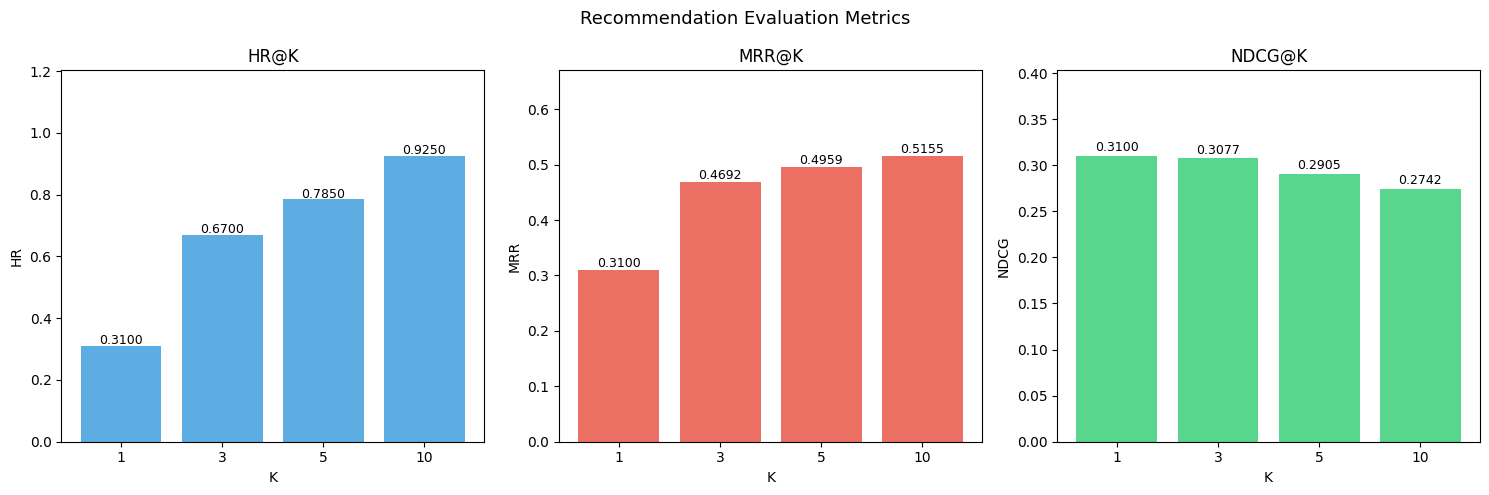

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metric_names = ["HR", "MRR", "NDCG"]
colors = ["#3498db", "#e74c3c", "#2ecc71"]

for ax, name, color in zip(axes, metric_names, colors):
    values = [ranking_metrics[k][name] for k in K_VALUES]
    ax.bar([str(k) for k in K_VALUES], values, color=color, alpha=0.8)
    ax.set_title(f"{name}@K")
    ax.set_xlabel("K")
    ax.set_ylabel(name)
    ax.set_ylim(0, max(values) * 1.3 if max(values) > 0 else 1.0)
    for i, v in enumerate(values):
        ax.text(i, v + 0.005, f"{v:.4f}", ha="center", fontsize=9)

plt.suptitle("Recommendation Evaluation Metrics", fontsize=13)
plt.tight_layout()
plt.show()


## 13. Extended Metrics (Coverage, Diversity, Novelty)

In [17]:
# Coverage
all_recommended = set()
for res in results:
    all_recommended.update(res["top_k_recs"][:MAX_K])
coverage = len(all_recommended) / len(movie_titles_set)
print(f"Coverage@{MAX_K}: {coverage:.4f} ({len(all_recommended)}/{len(movie_titles_set)} unique movies)")

def intra_list_diversity(ranked_list):
    if len(ranked_list) < 2:
        return 0.0
    genre_sets = []
    for movie in ranked_list:
        genres = adj.get(movie, {}).get("hasGenre", set())
        genre_sets.append(genres)
    distances = []
    for i in range(len(genre_sets)):
        for j in range(i + 1, len(genre_sets)):
            union = genre_sets[i] | genre_sets[j]
            inter = genre_sets[i] & genre_sets[j]
            distances.append(1.0 - len(inter) / len(union) if union else 1.0)
    return np.mean(distances) if distances else 0.0

diversities = [intra_list_diversity(res["top_k_recs"][:MAX_K]) for res in results]
avg_diversity = np.mean(diversities)
print(f"Avg Intra-List Diversity@{MAX_K}: {avg_diversity:.4f}")

# Novelty
item_popularity = {}
for movie in movie_titles_set:
    item_popularity[movie] = len(adj.get(movie, {}).get("rev_likes", set()))
max_popularity = max(item_popularity.values()) if item_popularity else 1

def novelty_score(ranked_list):
    if not ranked_list:
        return 0.0
    return np.mean([1.0 - item_popularity.get(m, 0) / max(max_popularity, 1) for m in ranked_list])

novelties = [novelty_score(res["top_k_recs"][:MAX_K]) for res in results]
avg_novelty = np.mean(novelties)
print(f"Avg Novelty@{MAX_K}: {avg_novelty:.4f}")

# Pattern distribution
pattern_counter = Counter()
for res in results:
    for pt in res.get("pattern_types", []):
        pattern_counter[pt] += 1
total_pats = sum(pattern_counter.values())
print(f"\nRecommendation Pattern Distribution:")
for pat, cnt in pattern_counter.most_common():
    print(f"  {pat}: {cnt} ({cnt/total_pats*100:.1f}%)")


Coverage@10: 0.3987 (61/153 unique movies)
Avg Intra-List Diversity@10: 0.9064
Avg Novelty@10: 0.5513

Recommendation Pattern Distribution:
  director: 1988 (99.4%)
  cast: 12 (0.6%)


## 14. Fairness Metrics: Per-Gender Breakdown

In [18]:
user_gender_map = build_user_gender_map(users_sub)
n_m = sum(1 for g in user_gender_map.values() if g == "M")
n_f = sum(1 for g in user_gender_map.values() if g == "F")
print(f"Gender map: {n_m} Male, {n_f} Female users")

group_metrics = compute_group_metrics(results, user_gender_map, K_VALUES)

print(f"\n{'K':>4} | {'HR_M':>7} | {'HR_F':>7} | {'MRR_M':>7} | {'MRR_F':>7} | {'NDCG_M':>8} | {'NDCG_F':>8}")
print("-" * 65)
for k in K_VALUES:
    gm = group_metrics["M"][k]
    gf = group_metrics["F"][k]
    print(f"{k:>4} | {gm['HR']:>7.4f} | {gf['HR']:>7.4f} | "
          f"{gm['MRR']:>7.4f} | {gf['MRR']:>7.4f} | "
          f"{gm['NDCG']:>8.4f} | {gf['NDCG']:>8.4f}")


NameError: name 'build_user_gender_map' is not defined

In [ ]:
# Coverage rate: % of test users who received >= 1 recommendation
users_with_recs = sum(1 for r in results if len(r['top_k_recs']) > 0)
users_no_recs   = sum(1 for r in results if len(r['top_k_recs']) == 0)
print(f'Coverage rate:    {users_with_recs}/{len(results)} users '
      f'({users_with_recs/len(results):.1%}) received recommendations')
print(f'No-rec users:     {users_no_recs} '
      f'({users_no_recs/len(results):.1%}) got empty lists')

# Per-gender coverage
for g in ('M', 'F'):
    g_results = [r for r in results if user_gender_map.get(r['user']) == g]
    g_covered = sum(1 for r in g_results if len(r['top_k_recs']) > 0)
    if g_results:
        print(f'  {g}: {g_covered}/{len(g_results)} '
              f'({g_covered/len(g_results):.1%})')


## 15. ILAP Fairness Metrics

In [ ]:
ilap = compute_all_ilap_metrics(results, user_gender_map, k=10, disadv="F", adv="M")
print_ilap_report(ilap, k=10, label="GPT-2 Path Model")


## 16. Additional Fairness Metrics

In [ ]:
print_additional_fairness_report(
    results, group_metrics, user_gender_map, adj,
    k_values=(5, 10), label="GPT-2 Path Model",
)


## 18. Comprehensive Report

In [ ]:
K_R = 10
cf_score, _ = counterfactual_fairness_score(results, user_gender_map, adj, K_R)
di = disparate_impact(group_metrics, K_R)
eo = equalized_opportunity(group_metrics, K_R)
dp = demographic_parity(results, user_gender_map, K_R)

print("=" * 60)
print("GPT-2 PATH MODEL - COMPREHENSIVE REPORT")
print(f"ML-1M | {MAX_USERS} users, {MAX_MOVIES} movies | K={K_R}")
print("=" * 60)

print("\n-- Accuracy --")
for k in K_VALUES:
    m = ranking_metrics[k]
    print(f"  HR@{k}={m['HR']:.4f}  MRR@{k}={m['MRR']:.4f}  NDCG@{k}={m['NDCG']:.4f}")

print(f"\n-- Extended --")
print(f"  Coverage@{MAX_K}:  {coverage:.4f}")
print(f"  Diversity@{MAX_K}: {avg_diversity:.4f}")
print(f"  Novelty@{MAX_K}:   {avg_novelty:.4f}")

print("\n-- ILAP Fairness --")
for key, val in ilap.items():
    if key != "KS_pval":
        print(f"  {key:<8} {val:.4f}")

print("\n-- Additional Fairness --")
print(f"  Disparate Impact@{K_R}:        {di:.4f}")
print(f"  Equalized Opportunity@{K_R}:   {eo:.4f}")
print(f"  Demographic Parity@{K_R}:      {dp:.4f}")
print(f"  Counterfactual Fairness@{K_R}: {cf_score:.4f}")

print("\n-- Pattern Distribution --")
for pat, cnt in pattern_counter.most_common():
    print(f"  {pat}: {cnt} ({cnt/total_pats*100:.1f}%)")

print("=" * 60)


## 19. Multi-Run Statistical Validation

In [ ]:
# import importlib
# import scripts.multi_run as multi_run
# importlib.reload(multi_run)
#
# SEEDS = [42, 123, 456]
#
# # Multi-run for our main model (demographic-blind GPT-2)
# our_runs = multi_run.run(
#     adj, all_users, test_set_dict, movie_titles_set,
#     user_gender_map, BASE_RELS, device,
#     paths_per_user=100, k_values=K_VALUES, seeds=SEEDS,
# )

In [ ]:
# multi_run.report(our_runs, k_values=K_VALUES)

## 20. GPT-2 + Gender

In [ ]:
import importlib
import scripts.baselines as baselines
importlib.reload(baselines)
K_VALUES = [1, 3, 5, 10]

results_gender, model_gender, vocab_g, id2tok_g, PAD_g, BOS_g, EOS_g, UNK_g, MAX_LEN_g = \
    baselines.run_gpt2_gender(
        test_set_dict, adj, all_users, movie_titles_set,
        BASE_RELS, device, k_values=K_VALUES,
        paths_per_user=100, gender_weight=0.20,
        epochs=8, lr=3e-4, patience=2, seed=42,
    )


In [ ]:
from metrics import (
    compute_group_metrics, compute_all_ilap_metrics, print_ilap_report,
    disparate_impact, equalized_opportunity, demographic_parity,
    counterfactual_fairness_score,
)
user_gender_map = build_user_gender_map(users_sub)

# ── Fairness results for single-seed GPT-2 + Gender run ──────────────────
group_metrics_g1 = compute_group_metrics(results_gender, user_gender_map, K_VALUES)

print(f"{'K':>4} | {'HR_M':>7} | {'HR_F':>7} | {'MRR_M':>7} | {'MRR_F':>7} | {'NDCG_M':>8} | {'NDCG_F':>8}")
print("-" * 65)
for k in K_VALUES:
    gm = group_metrics_g1["M"][k]
    gf = group_metrics_g1["F"][k]
    print(f"{k:>4} | {gm['HR']:>7.4f} | {gf['HR']:>7.4f} | "
          f"{gm['MRR']:>7.4f} | {gf['MRR']:>7.4f} | "
          f"{gm['NDCG']:>8.4f} | {gf['NDCG']:>8.4f}")

ilap_g1   = compute_all_ilap_metrics(results_gender, user_gender_map, k=10)
cf_g1, _  = counterfactual_fairness_score(results_gender, user_gender_map, adj, 10)
di_g1     = disparate_impact(group_metrics_g1, 10)
eo_g1     = equalized_opportunity(group_metrics_g1, 10)
dp_g1     = demographic_parity(results_gender, user_gender_map, 10)

print()
print(f"  Disparate Impact@10:        {di_g1:.4f}  (>=0.8 fair)")
print(f"  Equalized Opportunity@10:   {eo_g1:.4f}  (lower fairer)")
print(f"  Demographic Parity@10:      {dp_g1:.4f}  (lower fairer)")
print(f"  Counterfactual Fairness@10: {cf_g1:.4f}  (higher fairer)")

print()
print_ilap_report(ilap_g1, k=10, label="GPT-2 + Gender")


### Multi-Run: GPT-2 + Gender

In [ ]:
# import importlib
# import paths as _paths_mod
# import scripts.baselines as _bl
# importlib.reload(_bl)
#
# # Register gender sampler into the same `paths` module that multi_run uses
# _paths_mod._SAMPLERS["gender"] = _bl._sample_gender_cf_path
#
# GENDER_WEIGHTS = {
#     "genre": 0.20, "director": 0.16, "cf": 0.16,
#     "cast": 0.12, "composer": 0.08, "writer": 0.08,
#     "gender": 0.20,
# }
#
# try:
#     gender_runs = multi_run.run(
#         adj, all_users, test_set_dict, movie_titles_set,
#         user_gender_map, BASE_RELS | {"hasGender"}, device,
#         paths_per_user=100, k_values=K_VALUES, seeds=SEEDS,
#         pattern_weights=GENDER_WEIGHTS,
#     )
# finally:
#     _paths_mod._SAMPLERS.pop("gender", None)

In [ ]:
# multi_run.report(gender_runs, k_values=K_VALUES)

### Statistical Comparison: GPT-2 (Ours) vs GPT-2 + Gender

In [ ]:
# multi_run.compare(our_runs, gender_runs, k=10)

## 21. Fairness Metrics — GPT-2 vs GPT-2 + Gender

In [ ]:
from metrics import (
    compute_group_metrics, compute_all_ilap_metrics,
    disparate_impact, equalized_opportunity,
    demographic_parity, counterfactual_fairness_score,
)

# Group metrics
group_metrics_gender = compute_group_metrics(results_gender, user_gender_map, K_VALUES)

# Per-gender HR@K for both models
def gender_hr(gm, k):
    """Return (HR_M, HR_F) at k from group_metrics dict."""
    return gm["M"][k]["HR"], gm["F"][k]["HR"]

hr_m_ours,   hr_f_ours   = gender_hr(group_metrics,        10)
hr_m_gender, hr_f_gender = gender_hr(group_metrics_gender, 10)

# ILAP
ilap_ours   = compute_all_ilap_metrics(results,        user_gender_map, k=10)
ilap_gender = compute_all_ilap_metrics(results_gender, user_gender_map, k=10)

# Scalar fairness metrics
cf_ours,   _ = counterfactual_fairness_score(results,        user_gender_map, adj, 10)
cf_gender, _ = counterfactual_fairness_score(results_gender, user_gender_map, adj, 10)

di_ours   = disparate_impact(group_metrics,        10)
di_gender = disparate_impact(group_metrics_gender, 10)

eo_ours   = equalized_opportunity(group_metrics,        10)
eo_gender = equalized_opportunity(group_metrics_gender, 10)

dp_ours   = demographic_parity(results,        user_gender_map, 10)
dp_gender = demographic_parity(results_gender, user_gender_map, 10)


In [ ]:
# Print comparison table
k_r = 10
rm = ranking_metrics[k_r]
gm = evaluate_ranking(results_gender, k_values=K_VALUES)[k_r]

rows = [
    ("HR@10",    rm["HR"],    gm["HR"]),
    ("HR_M@10",  hr_m_ours,   hr_m_gender),
    ("HR_F@10",  hr_f_ours,   hr_f_gender),
    ("MRR@10",   rm["MRR"],   gm["MRR"]),
    ("NDCG@10",  rm["NDCG"],  gm["NDCG"]),
    ("", None, None),  # blank separator
    ("DI@10",    di_ours,     di_gender),
    ("EO@10",    eo_ours,     eo_gender),
    ("DP@10",    dp_ours,     dp_gender),
    ("CF@10",    cf_ours,     cf_gender),
]

sep = "-" * 60
print(sep)
print(f"{'Metric':<20}  {'GPT-2 (Ours)':>15}  {'GPT-2+Gender':>15}")
print(sep)
for name, v1, v2 in rows:
    if v1 is None:
        print()
        continue
    print(f"{name:<20}  {v1:>15.4f}  {v2:>15.4f}")
print(sep)


In [ ]:
# Per-gender breakdown table for both models
def print_gender_table(gm, label, k_values, gender_map):
    n_m = sum(1 for g in gender_map.values() if g == 'M')
    n_f = sum(1 for g in gender_map.values() if g == 'F')
    print()
    print(label)
    print(f'Gender map: {n_m} Male, {n_f} Female users')
    print()
    col = ' | '
    hdr = (f"{'K':>4}" + col + f"{'HR_M':>7}" + col + f"{'HR_F':>7}" + col
           + f"{'MRR_M':>7}" + col + f"{'MRR_F':>7}" + col
           + f"{'NDCG_M':>8}" + col + f"{'NDCG_F':>8}")
    print(hdr)
    print('-' * len(hdr))
    for k in k_values:
        m = gm['M'][k]
        f_ = gm['F'][k]
        print(
            f"{k:>4}" + col +
            f"{m['HR']:>7.4f}" + col +
            f"{f_['HR']:>7.4f}" + col +
            f"{m['MRR']:>7.4f}" + col +
            f"{f_['MRR']:>7.4f}" + col +
            f"{m['NDCG']:>8.4f}" + col +
            f"{f_['NDCG']:>8.4f}"
        )

print_gender_table(group_metrics,        '=== GPT-2 (Ours) ===',   K_VALUES, user_gender_map)
print_gender_table(group_metrics_gender, '=== GPT-2 + Gender ===', K_VALUES, user_gender_map)


In [ ]:
# ILAP side-by-side
all_keys = sorted(set(ilap_ours) | set(ilap_gender))
sep = "-" * 60
print()
print(sep)
print(f"{'ILAP Metric':<20}  {'GPT-2 (Ours)':>15}  {'GPT-2+Gender':>15}")
print(sep)
for key in all_keys:
    v1 = ilap_ours.get(key, float("nan"))
    v2 = ilap_gender.get(key, float("nan"))
    if isinstance(v1, (int, float)):
        print(f"{key:<20}  {v1:>15.4f}  {v2:>15.4f}")
    else:
        print(f"{key:<20}  {str(v1):>15}  {str(v2):>15}")
print(sep)


## 23. Per-K Fairness Table — Both Models

In [ ]:
# Fairness metrics at every K value — both models side by side
print('=' * 75)
print(f'{"Model":<20} {"K":>4} | {"HR_M":>7} {"HR_F":>7} {"Gap":>7} {"DI":>7} {"EO":>7}')
print('-' * 75)
for label, gm in [('GPT-2 (Ours)', group_metrics), ('GPT-2+Gender', group_metrics_gender)]:
    for k in K_VALUES:
        hr_m = gm['M'][k]['HR']
        hr_f = gm['F'][k]['HR']
        gap  = hr_f - hr_m
        denom = max(hr_m, hr_f)
        di   = min(hr_m, hr_f) / denom if denom > 0 else 1.0
        eo   = abs(gap)
        print(f'{label:<20} {k:>4} | {hr_m:>7.4f} {hr_f:>7.4f} {gap:>+7.4f} {di:>7.4f} {eo:>7.4f}')
    print('-' * 75)


## 24. Path Pattern Distribution by Gender

In [ ]:
import importlib
import scripts.metrics as _m
importlib.reload(_m)

print('=== GPT-2 (Ours) ===')
_m.print_path_fairness_report(results, user_gender_map, adj)

print('\n=== GPT-2 + Gender ===')
_m.print_path_fairness_report(results_gender, user_gender_map, adj)


## 22. Visualizations — GPT-2 vs GPT-2 + Gender

In [ ]:
import importlib
import scripts.visualizations as viz
importlib.reload(viz)

from metrics import evaluate_ranking

ranking_metrics_gender = evaluate_ranking(results_gender, k_values=K_VALUES)

# models: 3-tuple (results, ranking_metrics, group_metrics)
models = {
    "GPT-2 (Ours)": (results,        ranking_metrics,        group_metrics),
    "GPT-2+Gender": (results_gender, ranking_metrics_gender, group_metrics_gender),
}

# fairness_scores is passed separately (not inside the tuple)
fairness_scores = {
    "GPT-2 (Ours)": {"DI": di_ours,   "EO": eo_ours,   "DP": dp_ours,   "CF": cf_ours},
    "GPT-2+Gender": {"DI": di_gender, "EO": eo_gender, "DP": dp_gender, "CF": cf_gender},
}

ilap_scores = {
    "GPT-2 (Ours)": ilap_ours,
    "GPT-2+Gender": ilap_gender,
}

viz.plot_all(
    models=models,
    k_values=K_VALUES,
    save_dir="figures",
    ilap_scores=ilap_scores,
    fairness_scores=fairness_scores,
)


## 26. UserCF, SVD-MF, MLP-CF

In [ ]:
import importlib
import scripts.traditional_baselines as tb
importlib.reload(tb)
K_VALUES = [1, 3, 5, 10]
MAX_K = max(K_VALUES)

results_ucf, results_svd, results_mlp = tb.run_all(
    train_interactions, test_set_dict, movies_sub,
    k=MAX_K, seed=42, device=device,
    ucf_neighbors=20,
    svd_factors=50, svd_epochs=20,
    mlp_factors=32, mlp_epochs=20,
)
print("Done. UserCF / SVD-MF / MLP-CF results ready.")


In [ ]:
all_models = {
    "GPT-2": results,
    "UserCF":        results_ucf,
    "SVD-MF":        results_svd,
    "MLP-CF":        results_mlp,
}

tb.compare_all(all_models, user_gender_map, adj=adj, k_values=K_VALUES)